bordess

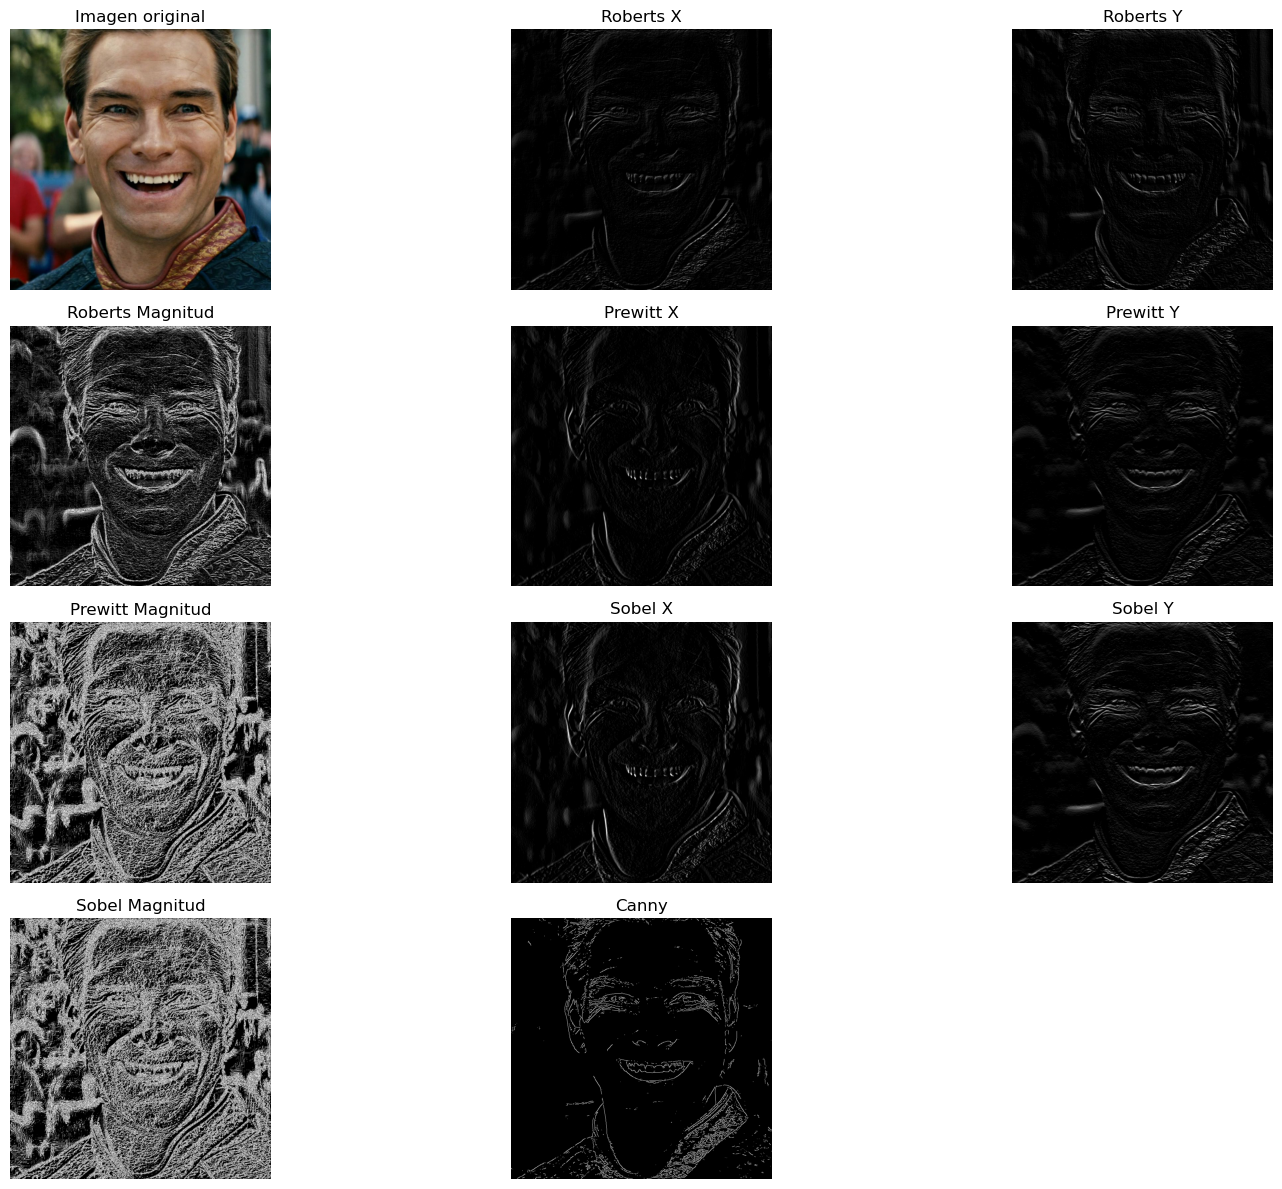

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img=cv2.imread('bordeshome.jpg')
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
robertx=np.array([[-1,0],[0,1]])
roberty=np.array([[0,-1],[1,0]])
robx_img=cv2.filter2D(gray,-1,robertx)
roby_img=cv2.filter2D(gray,-1,roberty)
rob_grad= np.sqrt(robx_img**2 + roby_img**2)
rob_grad_dir= np.arctan2(roby_img,robx_img)

#prewit :=)

prewitt_x=np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
prewitt_y=np.array([[-1,-1,-1],[0,0,0],[1,1,1]])
prex_img=cv2.filter2D(gray,-1,prewitt_x)
prey_img=cv2.filter2D(gray,-1,prewitt_y)
prewitt_mag=np.sqrt(prex_img**2 + prey_img**2)
prewitt_dir=np.arctan2(prey_img,prex_img)

#solbel

sobel_x=np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
sobel_y=np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
sobelx_img=cv2.filter2D(gray,-1,sobel_x)
sobely_img=cv2.filter2D(gray,-1,sobel_y)
sobel_mag=np.sqrt(sobelx_img**2 + sobely_img**2)
sobel_dir=np.arctan2(sobely_img,sobelx_img)

#canny
canny_img=cv2.Canny(gray,100,100)

rob_mag = np.uint8(np.clip(rob_grad, 0, 255))
robertx_img = np.uint8(np.clip(np.abs(robx_img), 0, 255))
roberty_img = np.uint8(np.clip(np.abs(roby_img), 0, 255))
prewitt_x_img = np.uint8(np.clip(np.abs(prex_img), 0, 255))
prewitt_y_img = np.uint8(np.clip(np.abs(prey_img), 0, 255))
prewitt_img = np.uint8(np.clip(prewitt_mag, 0, 255))
sobel_x_img = np.uint8(np.clip(np.abs(sobelx_img), 0, 255))
sobel_y_img = np.uint8(np.clip(np.abs(sobely_img), 0, 255))
sobel_img = np.uint8(np.clip(sobel_mag, 0, 255))
canny_img = np.uint8(np.clip(canny_img, 0, 255))

plt.figure(figsize=(16, 12))

plt.subplot(4, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen original')
plt.axis('off')

plt.subplot(4, 3, 2)
plt.imshow(robertx_img, cmap='gray')
plt.title('Roberts X')
plt.axis('off')

plt.subplot(4, 3, 3)
plt.imshow(roberty_img, cmap='gray')
plt.title('Roberts Y')
plt.axis('off')

plt.subplot(4, 3, 4)
plt.imshow(rob_mag, cmap='gray')
plt.title('Roberts Magnitud')
plt.axis('off')

plt.subplot(4, 3, 5)
plt.imshow(prewitt_x_img, cmap='gray')
plt.title('Prewitt X')
plt.axis('off')

plt.subplot(4, 3, 6)
plt.imshow(prewitt_y_img, cmap='gray')
plt.title('Prewitt Y')
plt.axis('off')

plt.subplot(4, 3, 7)
plt.imshow(prewitt_img, cmap='gray')
plt.title('Prewitt Magnitud')
plt.axis('off')

plt.subplot(4, 3, 8)
plt.imshow(sobel_x_img, cmap='gray')
plt.title('Sobel X')
plt.axis('off')

plt.subplot(4, 3, 9)
plt.imshow(sobel_y_img, cmap='gray')
plt.title('Sobel Y')
plt.axis('off')

plt.subplot(4, 3, 10)
plt.imshow(sobel_img, cmap='gray')
plt.title('Sobel Magnitud')
plt.axis('off')

plt.subplot(4, 3, 11)
plt.imshow(canny_img, cmap='gray')
plt.title('Canny')
plt.axis('off')

plt.tight_layout()
plt.show()

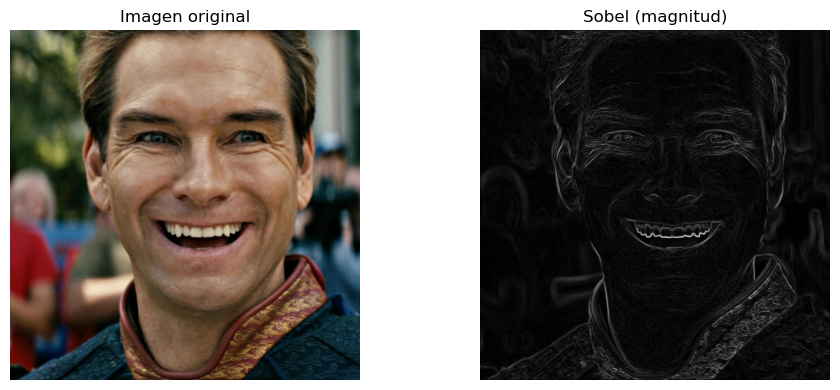

In [11]:
#sobel

import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    g_x = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=3)
    g_y = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=3)

    mag = np.sqrt(np.square(g_x) + np.square(g_y))
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    return mag

img = cv2.imread('bordeshome.jpg')

resultado_sobel = filtro_sobel(img)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(resultado_sobel, cmap='gray')
plt.title('Sobel (magnitud)')
plt.axis('off')

plt.tight_layout()
plt.show()

sobel mejorado

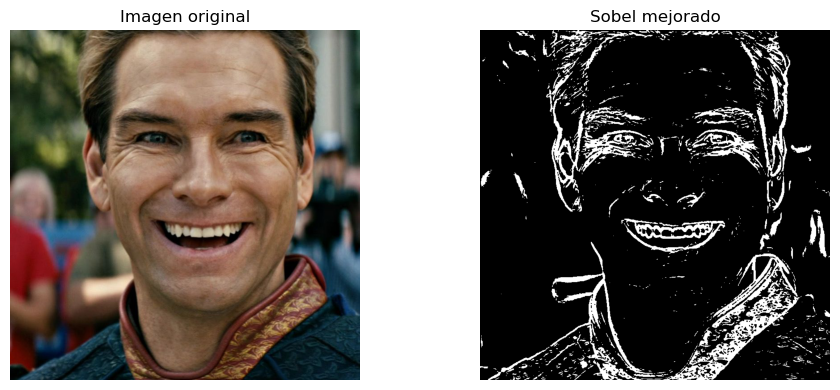

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobe_mejorado(img,kernel_size=3,umbral=30):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    #mejorar la deteccion filtro gauss
    img_gris = cv2.GaussianBlur(img_gris,(3,3),0)

    g_x = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=3)
    g_y = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=3)

    #mag = np.sqrt(np.square(g_x) + np.square(g_y))
    mag=np.sqrt(g_x**2 + g_y**2)
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    _,bordes=cv2.threshold(mag,umbral,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    #operacion morph unir bordes rotos
    kernel_m=np.ones((2,2),np.uint8)
    bordes=cv2.morphologyEx(bordes,cv2.MORPH_CLOSE,kernel_m)

    return bordes

img = cv2.imread('bordeshome.jpg')
resultado_bordes = filtro_sobe_mejorado(img)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(resultado_bordes, cmap='gray')
plt.title('Sobel mejorado')
plt.axis('off')

plt.tight_layout()
plt.show()

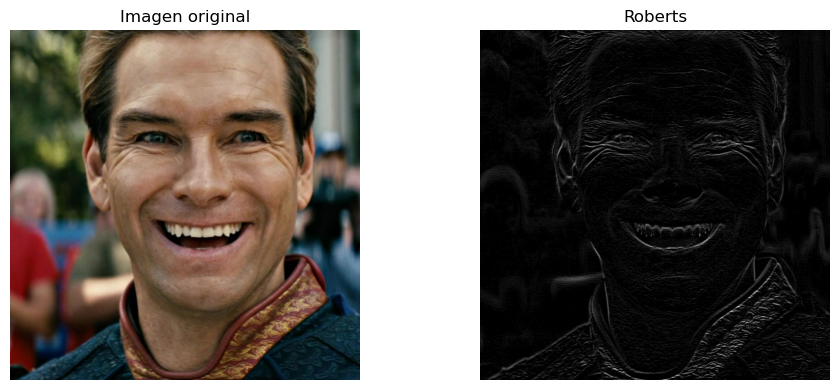

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_roberts(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    robertx = np.array([[-1, 0], [0, 1]], dtype=np.float32)
    roberty = np.array([[0, -1], [1, 0]], dtype=np.float32)
    r_x = cv2.filter2D(img_gris, -1, robertx)
    r_y = cv2.filter2D(img_gris, -1, roberty)
    roberts = cv2.addWeighted(r_x, 0.5, r_y, 0.5, 0)
    return roberts

img = cv2.imread('bordeshome.jpg')
resultado_roberts = filtro_roberts(img)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(resultado_roberts, cmap='gray')
plt.title('Roberts')
plt.axis('off')

plt.tight_layout()
plt.show()